In [1]:
from formatter import report_formatter
from analyzer import CodeAnalyzer
from state import AnalysisReport, NodeFlag

In [2]:
model_name = "gemini-2.5-flash-lite"

In [ ]:
analyzer = CodeAnalyzer(model_name)

# you can create the analyzer with custom key.
# analyzer = CodeAnalyzer(model_name, api_key = your_api_key)

# you can get your permanent api key with 'get_cached_key' method.
# analyzer.get_cached_key()

# you can set your permanent key with 'set_cached_key' method.
# analyzer.set_cached_key(your_api_key)

# you can check if you can any available api key with 'get_env_key' method.
# analyzer.get_env_key()

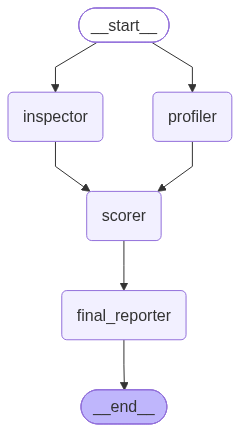

In [ ]:
# you can display the workflow graph image with 'display_graph_image' method.
analyzer.display_graph_image()

In [ ]:
# you can define your custom callback function.

def callback(data: AnalysisReport | NodeFlag):
    if isinstance(data, NodeFlag):
        start, end = "is started", "is completed"
        print(f"{data.worker_name} {start if data.flag else end}")

    if isinstance(data, AnalysisReport):
        profiler = data.profiler_report
        inspector = data.inspector_report
        scorer = data.scorer_report
        final_report = data.final_report

        if profiler:
            print(report_formatter(profiler_report = profiler))
        if inspector:
            print(report_formatter(inspector_report = inspector))
        if scorer:
            print(report_formatter(scorer_report = scorer))
        if final_report:
            print(final_report)

In [ ]:
code = """

import os
import sys
from typing import List, Optional, Dict
import json 

def calculate_sum(a, b):
    l = [] 
    result = a + b
    
    total = result + c # type: ignore
    return total

class dataProcessor:
    def __init__(self, initial_value):
        self.data_list: List[int] = []
        self.count = 0

    def process_items(self, items: List[str]) -> None:
        result = {}
        for item in items:
            l = len(item)
            result[item] = l
        
        return result
        self.count += 1

    def get_item(self, index: int) -> Optional[str]:
        l = len(self.data_list)
        if index < l:
            return self.data_list[index]
        return None

def process_data(data: List[int], flag: bool = True):
    def inner_func(items=[]): 
        return items

    l = data
    return inner_func(l)


"""

In [ ]:
# you can analyze your code directly.
analyzer.analyze(code, callback)

In [ ]:
# you can analyze your code asynchronously.
await analyzer.async_analyze(code, callback)

In [ ]:
# you can analyze your code directly from file.
analyzer.analyze_from_file("test_code.py", callback)

In [ ]:
# without callback, the functions returns graph state as a dictionary.

# result = analyzer.analyze(code)
# result = await analyzer.analyze(code)

result = analyzer.analyze_from_file("test_code.py")
print(result)